In [1]:
import os
import copy
import random
import numpy as np
import pandas as pd

from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms, models

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix

# Load the old CNN

In [2]:
# Use metal performance shaders (MPS) if available

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Usando dispositivo:", device)

#Load the model and configure for the device


model_path = "Models/Model_Exec_711_Epoch_150_cpu_portable_full.pt"

values = torch.load(model_path, map_location="cpu", weights_only=False)
model = values["modelo"]

model = model.to(device)
model.eval()

print("Modelo cargado correctamente")



Usando dispositivo: mps
Modelo cargado correctamente


# Capture the tensor and get the vector

In [3]:
#Tensor from model to vector[1024] extracter:

class CNNEmbeddingExtractor(nn.Module):
    def __init__(self, base_model):
        super().__init__()

        self.features = nn.ModuleList([
            nn.Sequential(*copy.deepcopy(block))
            for block in base_model.features
        ])

        self.second_level = copy.deepcopy(base_model.second_level)
        self.sizes = copy.deepcopy(base_model.sizes)

    def forward(self, image):
        x = image
        prev = -1
        pos = 0
        outputs = {}

        for i in range(len(self.features)):
            if i == 0 or i == 1:
                x = self.features[i](x)
                outputs[i] = x
            else:
                connections = self.second_level[pos:pos+prev]

                for c in range(len(connections)):
                    if connections[c] == 1:
                        skip_size = self.sizes[c][0]
                        req_size = x.shape[2]

                        if skip_size > req_size:
                            psize = skip_size - req_size + 1
                            pool = nn.MaxPool2d(kernel_size=psize, stride=1)
                            x2 = pool(outputs[c])

                        elif skip_size == req_size:
                            x2 = outputs[c]

                        else:
                            if (req_size - skip_size) % 2 == 0:
                                pad = int((req_size - skip_size) / 2)
                                padding = nn.ZeroPad2d(pad)
                                x2 = padding(outputs[c])
                            else:
                                pool = nn.MaxPool2d(kernel_size=2, stride=1, padding=1)
                                x2 = pool(outputs[c])
                                pad = int((req_size - skip_size - 1) / 2)
                                if pad > 0:
                                    padding = nn.ZeroPad2d(pad)
                                    x2 = padding(x2)

                        x = torch.cat((x, x2), axis=1)

                x = self.features[i](x)
                outputs[i] = x
                pos += prev

            prev += 1

        return torch.flatten(x, 1)

# Create the clinical vector

In [4]:
#Transformer for the image

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

In [5]:
#Check the csv
import pandas as pd

df = pd.read_csv("DataSet/dataset_maestro_od.csv")
print(df.shape)
print(df.columns.tolist())
df.head()

(365, 9)
['id', 'OD', 'external_id', 'Clase', 'Dx Periapical', 'Sensibilidad', 'Percusión', 'Movilidad', 'Palpación']


,id,OD,external_id,Clase,Dx Periapical,Sensibilidad,Percusión,Movilidad,Palpación
0,1. OD 22,22,radiografia_dataset_original/Pulpa Normal/1. O...,Pulpa Normal,Tejidos apicales normales,positivo,negativo,1,negativo
1,2. OD 25,25,radiografia_dataset_original/Pulpa Normal/2. O...,Pulpa Normal,Tejidos apicales normales,positivo,negativo,1,negativo
2,3. OD 14,14,radiografia_dataset_original/Pulpa Normal/3. O...,Pulpa Normal,Tejidos apicales normales,positivo,negativo,1,negativo
3,4. OD 25,25,radiografia_dataset_original/Pulpa Normal/4. O...,Pulpa Normal,Periodontitis apical sintomática,positivo,positivo,1,negativo
4,5. OD 27,27,radiografia_dataset_original/Pulpa Normal/5. O...,Pulpa Normal,Tejidos apicales normales,positivo,negativo,1,negativo


In [6]:
def build_clinical_vector(dx_periapical, sensibilidad, percusion, movilidad, palpacion, od):
    # Normalizar strings
    dx_periapical = str(dx_periapical).strip()
    sensibilidad = str(sensibilidad).strip().lower()
    percusion = str(percusion).strip().lower()
    movilidad = str(movilidad).strip()
    palpacion = str(palpacion).strip().lower()

    # Normalizar OD
    try:
        od = float(str(od).strip())
    except ValueError:
        raise ValueError(f"OD no válido: {od}")

    # Mapeo Dx Periapical
    dx_map = {
        "Periodontitis apical asintomática": [1, 0, 0, 0, 0],
        "Absceso apical crónico":            [0, 1, 0, 0, 0],
        "Periodontitis apical sintomática":  [0, 0, 1, 0, 0],
        "Tejidos apicales normales":         [0, 0, 0, 1, 0],
        "Absceso apical agudo":              [0, 0, 0, 0, 1],
    }

    # Binarias
    bin_map = {
        "positiva": 1.0,
        "positivo": 1.0,
        "negativa": 0.0,
        "negativo": 0.0,
    }

    # Movilidad
    movilidad_map = {
        "No valorable": [0, 0, 0],
        "1":            [1, 0, 0],
        "2":            [0, 1, 0],
        "3":            [0, 0, 1],
    }

    if dx_periapical not in dx_map:
        raise ValueError(f"Dx Periapical no válido: {dx_periapical}")

    if sensibilidad not in bin_map:
        raise ValueError(f"Sensibilidad no válida: {sensibilidad}")

    if percusion not in bin_map:
        raise ValueError(f"Percusión no válida: {percusion}")

    if palpacion not in bin_map:
        raise ValueError(f"Palpación no válida: {palpacion}")

    if movilidad not in movilidad_map:
        raise ValueError(f"Movilidad no válida: {movilidad}")

    vector = (
        dx_map[dx_periapical]
        + [bin_map[sensibilidad]]
        + [bin_map[percusion]]
        + movilidad_map[movilidad]
        + [bin_map[palpacion]]
        + [od]
    )

    return torch.tensor(vector, dtype=torch.float32)

In [8]:
#This aren't the clases for the vector, this is for the final classification of the model.

class_to_idx = {
    "Necrosis Pulpar": 0,
    "Previamente iniciado": 1,
    "Previamente Tratado": 2,
    "Pulpa Normal": 3,
    "Pulpitis Irreversible Asintomática": 4,
    "Pulpitis Irreversible Sintomática": 5,
    "Pulpitis Reversible": 6,
}

In [9]:
from pathlib import Path

def normalize_image_key(path):
    path = str(path).strip()

    # Unificar separadores
    path = path.replace("\\", "/")

    # Quitar prefijos posibles
    prefixes = [
        "DataSet/",
        "radiografia_dataset_original/",
        "DataSet/radiografia_dataset_original/",
    ]

    for prefix in prefixes:
        if path.startswith(prefix):
            path = path[len(prefix):]

    return path.strip("/")

# Data Loader

In [10]:
# Check the images
from pathlib import Path

def build_image_path_dict(root_dir, valid_exts=None):
    if valid_exts is None:
        valid_exts = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

    root_dir = Path(root_dir)
    image_path_dict = {}
    failed_files = []

    all_files = sorted(root_dir.rglob("*"))

    for file_path in all_files:
        if file_path.is_file() and file_path.suffix.lower() in valid_exts:
            try:
                relative_key = str(file_path.relative_to(root_dir))
                relative_key = normalize_image_key(relative_key)

                image_path_dict[relative_key] = str(file_path)

            except Exception as e:
                failed_files.append((str(file_path), str(e)))

    return image_path_dict, failed_files

In [11]:
%pwd

'/Users/mauricio/Documents/Ecuela-UV/Semestre-8/Servicio/DeepGA/AddVar'

In [12]:
# Build the image path dictionary
root_dir = "DataSet/radiografia_dataset_original"

image_path_dict, failed_files = build_image_path_dict(
    root_dir=root_dir
)

print("Número de imágenes indexadas:", len(image_path_dict))
print("Número de archivos con error:", len(failed_files))

first_keys = list(image_path_dict.keys())[:10]

for k in first_keys:
    print("Clave:", k)
    print("Ruta:", image_path_dict[k])
    print()

if failed_files:
    print("Archivos con error:")
    for path, err in failed_files[:30]:
        print(path)
        print("Error:", err)
        print("-" * 50)
else:
    print("No hubo errores.")

Número de imágenes indexadas: 366
Número de archivos con error: 0
Clave: Necrosis Pulpar/1. OD 36.jpeg
Ruta: DataSet/radiografia_dataset_original/Necrosis Pulpar/1. OD 36.jpeg

Clave: Necrosis Pulpar/10. OD 16.jpg
Ruta: DataSet/radiografia_dataset_original/Necrosis Pulpar/10. OD 16.jpg

Clave: Necrosis Pulpar/100. OD 16.jpg
Ruta: DataSet/radiografia_dataset_original/Necrosis Pulpar/100. OD 16.jpg

Clave: Necrosis Pulpar/11. OD 17.jpg
Ruta: DataSet/radiografia_dataset_original/Necrosis Pulpar/11. OD 17.jpg

Clave: Necrosis Pulpar/12. OD 46.jpg
Ruta: DataSet/radiografia_dataset_original/Necrosis Pulpar/12. OD 46.jpg

Clave: Necrosis Pulpar/13. OD 14.jpg
Ruta: DataSet/radiografia_dataset_original/Necrosis Pulpar/13. OD 14.jpg

Clave: Necrosis Pulpar/14. OD 16.jpg
Ruta: DataSet/radiografia_dataset_original/Necrosis Pulpar/14. OD 16.jpg

Clave: Necrosis Pulpar/15. OD 13.jpg
Ruta: DataSet/radiografia_dataset_original/Necrosis Pulpar/15. OD 13.jpg

Clave: Necrosis Pulpar/16. OD 36.jpg
Ruta: D

In [13]:
# Create the samples

samples = []
errors = []

for idx, row in df.iterrows():
    try:
        image_key = normalize_image_key(row["external_id"])

        if image_key not in image_path_dict:
            raise KeyError(f"No se encontró imagen para: {image_key}")

        clinical_vector = build_clinical_vector(
            dx_periapical=row["Dx Periapical"],
            sensibilidad=row["Sensibilidad"],
            percusion=row["Percusión"],
            movilidad=row["Movilidad"],
            palpacion=row["Palpación"],
            od=row["OD"],
        )

        if row["Clase"] not in class_to_idx:
            raise KeyError(f"Clase no válida: {row['Clase']}")

        label = class_to_idx[row["Clase"]]

        samples.append({
            "image_key": image_key,
            "image_path": image_path_dict[image_key],  
            "clinical_vector": clinical_vector,         # [12]
            "label": label,                             # int
        })

    except Exception as e:
        errors.append({
            "row_idx": idx,
            "id": row.get("id", None),
            "external_id": row.get("external_id", None),
            "clase": row.get("Clase", None),
            "dx_periapical": row.get("Dx Periapical", None),
            "sensibilidad": row.get("Sensibilidad", None),
            "percusion": row.get("Percusión", None),
            "movilidad": row.get("Movilidad", None),
            "palpacion": row.get("Palpación", None),
            "error": str(e),
        })

print("Samples válidos:", len(samples))
print("Errores:", len(errors))

for err in errors:
    print("=" * 80)
    print(f"Fila: {err['row_idx']}")
    print(f"id: {err['id']}")
    print(f"external_id: {err['external_id']}")
    print(f"Clase: {err['clase']}")
    print(f"Dx Periapical: {err['dx_periapical']}")
    print(f"Sensibilidad: {err['sensibilidad']}")
    print(f"Percusión: {err['percusion']}")
    print(f"Movilidad: {err['movilidad']}")
    print(f"Palpación: {err['palpacion']}")
    print(f"Error: {err['error']}")

Samples válidos: 364
Errores: 1
Fila: 321
id: 26. OD 21
external_id: Previamente iniciado/26. OD 21.jpg
Clase: Previamente iniciado
Dx Periapical: Tejidos apicales normales
Sensibilidad: negativo
Percusión: negativo
Movilidad: 1
Palpación: negativo
Error: 'No se encontró imagen para: Previamente iniciado/26. OD 21.jpg'


In [14]:
# Data set Class for the stratification
from torch.utils.data import Dataset
from PIL import Image
import torch

class FullMultimodalFolderDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform
        self.targets = [s["label"] for s in samples]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]

        image = Image.open(sample["image_path"]).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)

        clinical = torch.tensor(sample["clinical_vector"], dtype=torch.float32)
        label = torch.tensor(sample["label"], dtype=torch.long)

        return image, clinical, label

In [15]:
# make the stratified splits

import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit

def make_stratified_splits(targets, val_split=0.15, test_split=0.15, seed=42):
    y = np.array(targets)
    idx = np.arange(len(y))

    # train+val vs test
    sss_test = StratifiedShuffleSplit(
        n_splits=1,
        test_size=test_split,
        random_state=seed
    )
    trainval_idx, test_idx = next(sss_test.split(idx, y))

    # train vs val
    y_trainval = y[trainval_idx]
    val_rel = val_split / (1.0 - test_split)

    sss_val = StratifiedShuffleSplit(
        n_splits=1,
        test_size=val_rel,
        random_state=seed
    )
    train_rel, val_rel_idx = next(sss_val.split(trainval_idx, y_trainval))

    train_idx = trainval_idx[train_rel]
    val_idx = trainval_idx[val_rel_idx]

    return {
        "train_idx": train_idx,
        "val_idx": val_idx,
        "test_idx": test_idx,
    }

In [16]:
# Data loader

import torch
from torch.utils.data import DataLoader, Subset

def make_multimodal_dataloaders(
    ds,
    train_idx,
    val_idx,
    test_idx,
    batch_size=64,
    num_workers=4,
    seed=42,
):
    g = torch.Generator()
    g.manual_seed(seed)

    pin = torch.backends.mps.is_available()

    train_dl = DataLoader(
        Subset(ds, train_idx),
        batch_size=batch_size,
        shuffle=True,
        generator=g,
        num_workers=num_workers,
        pin_memory=pin,
    )

    val_dl = DataLoader(
        Subset(ds, val_idx),
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin,
    )

    test_dl = DataLoader(
        Subset(ds, test_idx),
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin,
    )

    return {
        "train": train_dl,
        "val": val_dl,
        "test": test_dl,
    }

In [17]:
# Use the Data loader
def load_data_module(
    samples,
    batch_size=64,
    val_split=0.15,
    test_split=0.15,
    seed=42,
    num_workers=0
):
    ds = FullMultimodalFolderDataset(
        samples=samples,
        transform=transform
    )

    splits = make_stratified_splits(
        targets=ds.targets,
        val_split=val_split,
        test_split=test_split,
        seed=seed,
    )

    loaders = make_multimodal_dataloaders(
        ds=ds,
        train_idx=splits["train_idx"],
        val_idx=splits["val_idx"],
        test_idx=splits["test_idx"],
        batch_size=batch_size,
        num_workers=num_workers,
        seed=seed,
    )

    return {
        "dataset": ds,
        "loaders": loaders,
        "splits": splits,
    }

In [18]:
# Functions to show the distribution of classes in each split
from collections import Counter

def show_split_distribution(ds, split_idx, name, idx_to_class):
    labels = [ds.targets[i] for i in split_idx]
    counts = Counter(labels)
    total = len(labels)

    print(f"\n{name} total = {total}")
    for class_idx in sorted(idx_to_class.keys()):
        class_name = idx_to_class[class_idx]
        n = counts.get(class_idx, 0)
        pct = (n / total) * 100 if total > 0 else 0
        print(f"  {class_name:<35} {n:>3}  ({pct:>5.2f}%)")


def print_data_module_summary(data_module, class_to_idx):
    ds = data_module["dataset"]
    splits = data_module["splits"]

    train_idx = splits["train_idx"]
    val_idx = splits["val_idx"]
    test_idx = splits["test_idx"]

    idx_to_class = {v: k for k, v in class_to_idx.items()}

    print(f"Counts: {len(train_idx)} {len(val_idx)} {len(test_idx)}")

    show_split_distribution(ds, train_idx, "TRAIN", idx_to_class)
    show_split_distribution(ds, val_idx, "VAL", idx_to_class)
    show_split_distribution(ds, test_idx, "TEST", idx_to_class)

    all_idx = np.concatenate([train_idx, val_idx, test_idx])
    print("¿Índices únicos?", len(all_idx) == len(set(all_idx)))
    print("¿Algún índice fuera de rango?", max(all_idx) >= len(ds))
    

In [19]:
#Show the distribution of classes in each split
data_module = load_data_module(samples, num_workers=0)

print_data_module_summary(data_module, class_to_idx)

Counts: 254 55 55

TRAIN total = 254
  Necrosis Pulpar                      70  (27.56%)
  Previamente iniciado                 17  ( 6.69%)
  Previamente Tratado                  30  (11.81%)
  Pulpa Normal                         43  (16.93%)
  Pulpitis Irreversible Asintomática   39  (15.35%)
  Pulpitis Irreversible Sintomática    52  (20.47%)
  Pulpitis Reversible                   3  ( 1.18%)

VAL total = 55
  Necrosis Pulpar                      15  (27.27%)
  Previamente iniciado                  4  ( 7.27%)
  Previamente Tratado                   6  (10.91%)
  Pulpa Normal                          9  (16.36%)
  Pulpitis Irreversible Asintomática    9  (16.36%)
  Pulpitis Irreversible Sintomática    11  (20.00%)
  Pulpitis Reversible                   1  ( 1.82%)

TEST total = 55
  Necrosis Pulpar                      15  (27.27%)
  Previamente iniciado                  4  ( 7.27%)
  Previamente Tratado                   7  (12.73%)
  Pulpa Normal                          9  (16

# Create the new model

In [20]:
import torch
import torch.nn as nn

class FusedClassifier(nn.Module):
    def __init__(
        self,
        input_dim=18444,
        num_classes=6,
        dropout=0.2,
    ):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.2), 
            nn.Linear(256, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.2),  
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        return self.net(x)

In [21]:
#Create the full model

class FullMultimodalDentalDeppGAModel(nn.Module):
    def __init__(self, embedding_extractor, fused_classifier):
        super().__init__()
        self.embedding_extractor = embedding_extractor
        self.fused_classifier = fused_classifier

    def forward(self, image, clinical_vector):
        embedding = self.embedding_extractor(image)         
        x = torch.cat([embedding, clinical_vector], dim=1)  
        logits = self.fused_classifier(x)                    # [B, 7]
        return logits

In [22]:
#Testing if the model exists

clinical_dim = len(samples[0]["clinical_vector"])
num_classes = len(class_to_idx)
embedding_dim = 18432

print("clinical_dim:", clinical_dim)
print("num_classes:", num_classes)

extractor = CNNEmbeddingExtractor(model)

fused_classifier = FusedClassifier(
    input_dim=embedding_dim + clinical_dim,
    num_classes=num_classes,
)

full_model = FullMultimodalDentalDeppGAModel(
    embedding_extractor=extractor,
    fused_classifier=fused_classifier,
).to(device)

print(full_model)

clinical_dim: 12
num_classes: 7
FullMultimodalDentalDeppGAModel(
  (embedding_extractor): CNNEmbeddingExtractor(
    (features): ModuleList(
      (0): Sequential(
        (0): Conv2d(1, 8, kernel_size=(5, 5), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): AvgPool2d(kernel_size=2, stride=2, padding=0)
      )
      (1): Sequential(
        (0): Conv2d(8, 8, kernel_size=(9, 9), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
      (2): Sequential(
        (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
      (3): Sequential(
        (0): Conv2d(16, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)

In [23]:
#Testing if the model can process a batch of data

train_loader = data_module["loaders"]["train"]

images, clinical_vectors, labels = next(iter(train_loader))

images = images.to(device)
clinical_vectors = clinical_vectors.to(device)
labels = labels.to(device)

with torch.no_grad():
    embedding = full_model.embedding_extractor(images)
    outputs = full_model(images, clinical_vectors)

print("images:", images.shape)
print("clinical_vectors:", clinical_vectors.shape)
print("embedding:", embedding.shape)
print("labels:", labels.shape)
print("outputs:", outputs.shape)

/Users/mauricio/Documents/Ecuela-UV/Semestre-8/Servicio/DeepGA/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/var/folders/tl/kwq3tjcj1ys7lmb1pyf3jdd80000gn/T/ipykernel_22694/2383641742.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  clinical = torch.tensor(sample["clinical_vector"], dtype=torch.float32)


images: torch.Size([64, 1, 128, 128])
clinical_vectors: torch.Size([64, 12])
embedding: torch.Size([64, 18432])
labels: torch.Size([64])
outputs: torch.Size([64, 7])


In [24]:
images, clinical_vectors, labels = next(iter(train_loader))
print("labels en el batch:", labels)
print("unique labels:", labels.unique())
print("clinical_vectors muestra:", clinical_vectors[0])

/var/folders/tl/kwq3tjcj1ys7lmb1pyf3jdd80000gn/T/ipykernel_22694/2383641742.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  clinical = torch.tensor(sample["clinical_vector"], dtype=torch.float32)


labels en el batch: tensor([2, 0, 2, 0, 4, 0, 3, 0, 5, 5, 0, 5, 5, 1, 2, 1, 5, 0, 5, 3, 4, 5, 4, 1,
        1, 2, 5, 2, 6, 0, 2, 0, 4, 0, 2, 5, 5, 0, 0, 4, 0, 0, 0, 1, 3, 4, 4, 5,
        3, 6, 5, 0, 4, 5, 5, 3, 3, 3, 3, 5, 3, 5, 2, 3])
unique labels: tensor([0, 1, 2, 3, 4, 5, 6])
clinical_vectors muestra: tensor([ 0.,  0.,  0.,  1.,  0.,  0.,  0.,  1.,  0.,  0.,  0., 12.])


# Training the Full Model

In [25]:
import torch
import torch.nn as nn
import copy

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

if device.type == "mps":
    torch.set_float32_matmul_precision("high")
    print("MPS disponible")
else:
    print("Usando:", device)

full_model = full_model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW([
        {"params": full_model.embedding_extractor.parameters(), "lr": 1e-6},
        {"params": full_model.fused_classifier.parameters(), "lr": 3e-4},
    ], weight_decay=5e-4)

MPS disponible


In [26]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device,
):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, clinical_vectors, labels in loader:
        images = images.to(device)
        clinical_vectors = clinical_vectors.to(device)
        labels = labels.to(device)

        optimizer.zero_grad(set_to_none=True)

        outputs = model(images, clinical_vectors)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        preds = outputs.argmax(dim=1)

        batch_total = labels.size(0)
        running_loss += loss.item() * batch_total
        correct += (preds == labels).sum().item()
        total += batch_total

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [27]:
#Test if the model can train
train_loss, train_acc = train_one_epoch(
    full_model,
    data_module["loaders"]["train"],
    criterion,
    optimizer,
    device,
)

print(f"train_loss = {train_loss:.4f}")
print(f"train_acc  = {train_acc:.4f}")

/var/folders/tl/kwq3tjcj1ys7lmb1pyf3jdd80000gn/T/ipykernel_22694/2383641742.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  clinical = torch.tensor(sample["clinical_vector"], dtype=torch.float32)


train_loss = 1.8587
train_acc  = 0.2795


In [28]:
def evaluate_one_epoch(
    model,
    loader,
    criterion,
    device,
):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.inference_mode():
        for images, clinical_vectors, labels in loader:
            images = images.to(device)
            clinical_vectors = clinical_vectors.to(device)
            labels = labels.to(device)

            outputs = model(images, clinical_vectors)
            loss = criterion(outputs, labels)

            preds = outputs.argmax(dim=1)

            batch_total = labels.size(0)
            running_loss += loss.item() * batch_total
            correct += (preds == labels).sum().item()
            total += batch_total

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [29]:
def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=50,
    min_acc_delta=0.01,
):
    best_model_wts = copy.deepcopy(model.state_dict())

    best_val_acc = 0.0
    best_val_loss = float("inf")
    best_epoch = 0

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
    }

    scaler = torch.amp.GradScaler("mps") if device.type == "mps" else None

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(
            model=model,
            loader=train_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=device,
        )

        val_loss, val_acc = evaluate_one_epoch(
            model=model,
            loader=val_loader,
            criterion=criterion,
            device=device,
        )

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch + 1:02d}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f}"
        )

        acc_improved = val_acc > best_val_acc + min_acc_delta
        acc_similar_but_loss_better = (
            abs(val_acc - best_val_acc) <= min_acc_delta
            and val_loss < best_val_loss
        )

        if acc_improved or acc_similar_but_loss_better:
            best_val_acc = val_acc
            best_val_loss = val_loss
            best_epoch = epoch + 1
            best_model_wts = copy.deepcopy(model.state_dict())

            print(
                f"  ✅ Nuevo mejor modelo | "
                f"Epoch {best_epoch} | "
                f"Val Acc: {best_val_acc:.4f} | "
                f"Val Loss: {best_val_loss:.4f}"
            )

    model.load_state_dict(best_model_wts)

    print("\nMejor modelo:")
    print(f"Epoch: {best_epoch}")
    print(f"Val Acc: {best_val_acc:.4f}")
    print(f"Val Loss: {best_val_loss:.4f}")

    return model, history

In [30]:
train_loader = data_module["loaders"]["train"]
val_loader = data_module["loaders"]["val"]

#train_full_model, history = train_model(
#    model=full_model,
#    train_loader=train_loader,
#    val_loader=val_loader,
#    criterion=criterion,
#    optimizer=optimizer,
#    device=device,
#    epochs=50,
#)

In [31]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)

@torch.no_grad()
def get_predictions(model, loader, device):
    model.eval()

    all_preds = []
    all_targets = []

    for images, clinical_vectors, labels in loader:
        images = images.to(device, non_blocking=True)
        clinical_vectors = clinical_vectors.to(device, non_blocking=True)

        logits = model(images, clinical_vectors)
        preds = torch.argmax(logits, dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_targets.extend(labels.numpy())

    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)

    return all_targets, all_preds


def evaluate_classification_model(model, loader, device, idx_to_class):
    y_true, y_pred = get_predictions(model, loader, device)

    acc = accuracy_score(y_true, y_pred)

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )

    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )

    labels = sorted(idx_to_class.keys())
    target_names = [idx_to_class[i] for i in labels]

    cm = confusion_matrix(y_true, y_pred, labels=labels)

    report = classification_report(
        y_true,
        y_pred,
        labels=labels,
        target_names=target_names,
        zero_division=0,
    )

    results = {
        "accuracy": acc,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "precision_weighted": precision_weighted,
        "recall_weighted": recall_weighted,
        "f1_weighted": f1_weighted,
        "confusion_matrix": cm,
        "classification_report": report,
        "y_true": y_true,
        "y_pred": y_pred,
    }

    return results

In [32]:
idx_to_class = {v: k for k, v in class_to_idx.items()}

results = evaluate_classification_model(
    #model=train_full_model,
    model=full_model,
    loader=data_module["loaders"]["test"],
    device=device,
    idx_to_class=idx_to_class,
)

print(f"Accuracy           : {results['accuracy']:.4f}")
print(f"Precision macro    : {results['precision_macro']:.4f}")
print(f"Recall macro       : {results['recall_macro']:.4f}")
print(f"F1 macro           : {results['f1_macro']:.4f}")
print(f"Precision weighted : {results['precision_weighted']:.4f}")
print(f"Recall weighted    : {results['recall_weighted']:.4f}")
print(f"F1 weighted        : {results['f1_weighted']:.4f}")

print("\nClassification report:\n")
print(results["classification_report"])

print("Confusion matrix:\n")
print(results["confusion_matrix"])

/var/folders/tl/kwq3tjcj1ys7lmb1pyf3jdd80000gn/T/ipykernel_22694/2383641742.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  clinical = torch.tensor(sample["clinical_vector"], dtype=torch.float32)


Accuracy           : 0.2000
Precision macro    : 0.1450
Recall macro       : 0.1728
F1 macro           : 0.1125
Precision weighted : 0.1875
Recall weighted    : 0.2000
F1 weighted        : 0.1358

Classification report:

                                    precision    recall  f1-score   support

                   Necrosis Pulpar       0.00      0.00      0.00        15
              Previamente iniciado       0.00      0.00      0.00         4
               Previamente Tratado       0.00      0.00      0.00         7
                      Pulpa Normal       0.19      0.78      0.31         9
Pulpitis Irreversible Asintomática       0.15      0.25      0.19         8
 Pulpitis Irreversible Sintomática       0.67      0.18      0.29        11
               Pulpitis Reversible       0.00      0.00      0.00         1

                          accuracy                           0.20        55
                         macro avg       0.14      0.17      0.11        55
                 

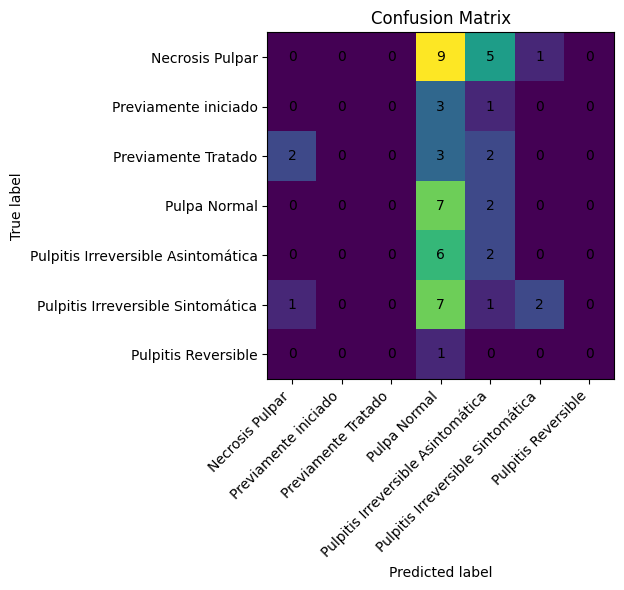

In [33]:
import matplotlib.pyplot as plt

def plot_confusion_matrix(cm, idx_to_class):
    labels = [idx_to_class[i] for i in sorted(idx_to_class.keys())]

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm)

    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))

    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticklabels(labels)

    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title("Confusion Matrix")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center")

    plt.tight_layout()
    plt.show()

plot_confusion_matrix(results["confusion_matrix"], idx_to_class)


# Combinations of the Colums

In [34]:
from itertools import combinations

clinical_columns = [
    "Dx Periapical",
    "Sensibilidad",
    "Percusión",
    "Movilidad",
    "Palpación",
    "OD",
]

clinical_combinations = []

for r in range(1, len(clinical_columns) + 1):
    clinical_combinations.extend(combinations(clinical_columns, r))

clinical_combinations = [tuple(c) for c in clinical_combinations]

print("Total combinaciones:", len(clinical_combinations))

for i, combo in enumerate(clinical_combinations, start=1):
    print(i, combo)

Total combinaciones: 63
1 ('Dx Periapical',)
2 ('Sensibilidad',)
3 ('Percusión',)
4 ('Movilidad',)
5 ('Palpación',)
6 ('OD',)
7 ('Dx Periapical', 'Sensibilidad')
8 ('Dx Periapical', 'Percusión')
9 ('Dx Periapical', 'Movilidad')
10 ('Dx Periapical', 'Palpación')
11 ('Dx Periapical', 'OD')
12 ('Sensibilidad', 'Percusión')
13 ('Sensibilidad', 'Movilidad')
14 ('Sensibilidad', 'Palpación')
15 ('Sensibilidad', 'OD')
16 ('Percusión', 'Movilidad')
17 ('Percusión', 'Palpación')
18 ('Percusión', 'OD')
19 ('Movilidad', 'Palpación')
20 ('Movilidad', 'OD')
21 ('Palpación', 'OD')
22 ('Dx Periapical', 'Sensibilidad', 'Percusión')
23 ('Dx Periapical', 'Sensibilidad', 'Movilidad')
24 ('Dx Periapical', 'Sensibilidad', 'Palpación')
25 ('Dx Periapical', 'Sensibilidad', 'OD')
26 ('Dx Periapical', 'Percusión', 'Movilidad')
27 ('Dx Periapical', 'Percusión', 'Palpación')
28 ('Dx Periapical', 'Percusión', 'OD')
29 ('Dx Periapical', 'Movilidad', 'Palpación')
30 ('Dx Periapical', 'Movilidad', 'OD')
31 ('Dx Peria

In [35]:
def build_clinical_vector_by_columns(row, selected_columns):
    vector = []

    # Dx Periapical
    dx_map = {
        "Periodontitis apical asintomática": [1, 0, 0, 0, 0],
        "Absceso apical crónico":            [0, 1, 0, 0, 0],
        "Periodontitis apical sintomática":  [0, 0, 1, 0, 0],
        "Tejidos apicales normales":         [0, 0, 0, 1, 0],
        "Absceso apical agudo":              [0, 0, 0, 0, 1],
    }

    # Binarias
    bin_map = {
        "positiva": 1.0,
        "positivo": 1.0,
        "negativa": 0.0,
        "negativo": 0.0,
    }

    # Movilidad
    movilidad_map = {
        "No valorable": [0, 0, 0],
        "1":            [1, 0, 0],
        "2":            [0, 1, 0],
        "3":            [0, 0, 1],
    }

    for column in selected_columns:

        if column == "Dx Periapical":
            value = str(row["Dx Periapical"]).strip()

            if value not in dx_map:
                raise ValueError(f"Dx Periapical no válido: {value}")

            vector.extend(dx_map[value])

        elif column == "Sensibilidad":
            value = str(row["Sensibilidad"]).strip().lower()

            if value not in bin_map:
                raise ValueError(f"Sensibilidad no válida: {value}")

            vector.append(bin_map[value])

        elif column == "Percusión":
            value = str(row["Percusión"]).strip().lower()

            if value not in bin_map:
                raise ValueError(f"Percusión no válida: {value}")

            vector.append(bin_map[value])

        elif column == "Movilidad":
            value = str(row["Movilidad"]).strip()

            if value not in movilidad_map:
                raise ValueError(f"Movilidad no válida: {value}")

            vector.extend(movilidad_map[value])

        elif column == "Palpación":
            value = str(row["Palpación"]).strip().lower()

            if value not in bin_map:
                raise ValueError(f"Palpación no válida: {value}")

            vector.append(bin_map[value])

        elif column == "OD":
            value = str(row["OD"]).strip()

            try:
                value = float(value)
            except ValueError:
                raise ValueError(f"OD no válido: {value}")

            vector.append(value)

        else:
            raise ValueError(f"Columna clínica no reconocida: {column}")

    return torch.tensor(vector, dtype=torch.float32)

In [36]:
def create_samples_for_combination(selected_columns):
    combo_samples = []
    combo_errors = []

    for idx, row in df.iterrows():
        try:
            image_key = normalize_image_key(row["external_id"])

            if image_key not in image_path_dict:
                raise KeyError(f"No se encontró imagen para: {image_key}")

            clinical_vector = build_clinical_vector_by_columns(
                row=row,
                selected_columns=selected_columns,
            )

            if row["Clase"] not in class_to_idx:
                raise KeyError(f"Clase no válida: {row['Clase']}")

            label = class_to_idx[row["Clase"]]

            combo_samples.append({
                "image_key": image_key,
                "image_path": image_path_dict[image_key],
                "clinical_vector": clinical_vector,
                "label": label,
            })

        except Exception as e:
            combo_errors.append({
                "row_idx": idx,
                "id": row.get("id", None),
                "external_id": row.get("external_id", None),
                "clase": row.get("Clase", None),
                "selected_columns": selected_columns,
                "error": str(e),
            })

    return combo_samples, combo_errors

In [37]:
test_combo = (
    "Dx Periapical",
    "Sensibilidad",
    "Movilidad",
    "Palpación",
)

combo_samples, combo_errors = create_samples_for_combination(test_combo)

print("Combinación:", test_combo)
print("Samples válidos:", len(combo_samples))
print("Errores:", len(combo_errors))
print("Tamaño vector clínico:", len(combo_samples[0]["clinical_vector"]))

if combo_errors:
    print(combo_errors[:5])

Combinación: ('Dx Periapical', 'Sensibilidad', 'Movilidad', 'Palpación')
Samples válidos: 364
Errores: 1
Tamaño vector clínico: 10
[{'row_idx': 321, 'id': '26. OD 21', 'external_id': 'Previamente iniciado/26. OD 21.jpg', 'clase': 'Previamente iniciado', 'selected_columns': ('Dx Periapical', 'Sensibilidad', 'Movilidad', 'Palpación'), 'error': "'No se encontró imagen para: Previamente iniciado/26. OD 21.jpg'"}]


In [38]:
test_combo = ("OD",)

combo_samples, combo_errors = create_samples_for_combination(test_combo)

print("Combinación:", test_combo)
print("Samples válidos:", len(combo_samples))
print("Errores:", len(combo_errors))
print("Tamaño vector clínico:", len(combo_samples[0]["clinical_vector"]))

Combinación: ('OD',)
Samples válidos: 364
Errores: 1
Tamaño vector clínico: 1


In [39]:
import copy
import pandas as pd

def build_model_for_clinical_dim(clinical_dim):
    embedding_dim = 18432
    input_dim = embedding_dim + clinical_dim

    fresh_extractor = copy.deepcopy(extractor)

    fused_classifier = FusedClassifier(
        input_dim=input_dim,
        num_classes=num_classes,
    )

    model = FullMultimodalDentalDeppGAModel(
        embedding_extractor=fresh_extractor,
        fused_classifier=fused_classifier,
    ).to(device)

    return model

In [40]:
combination_results = {}

def run_combination_experiment(
    selected_columns,
    batch_size=64,
    epochs=50,
    val_split=0.15,
    test_split=0.15,
    seed=42,
):
    print("\n" + "=" * 80)
    print("Combinación:", selected_columns)
    print("=" * 80)

    combo_samples, combo_errors = create_samples_for_combination(selected_columns)

    if len(combo_samples) == 0:
        raise ValueError(f"No hay samples válidos para {selected_columns}")

    clinical_dim = len(combo_samples[0]["clinical_vector"])
    print("Samples:", len(combo_samples))
    print("Errores:", len(combo_errors))
    print("Clinical dim:", clinical_dim)

    combo_data_module = load_data_module(
        samples=combo_samples,
        batch_size=batch_size,
        val_split=val_split,
        test_split=test_split,
        seed=seed,
        num_workers=0,
    )

    model = build_model_for_clinical_dim(clinical_dim)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.AdamW([
        {"params": model.embedding_extractor.parameters(), "lr": 1e-6},
        {"params": model.fused_classifier.parameters(), "lr": 3e-4},
    ], weight_decay=5e-4)

    trained_model, history = train_model(
        model=model,
        train_loader=combo_data_module["loaders"]["train"],
        val_loader=combo_data_module["loaders"]["val"],
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        epochs=epochs,
    )

    results = evaluate_classification_model(
        model=trained_model,
        loader=combo_data_module["loaders"]["test"],
        device=device,
        idx_to_class=idx_to_class,
    )

    print("\nAccuracy:", results["accuracy"])
    print("F1 macro:", results["f1_macro"])
    print("\nClassification report:")
    print(results["classification_report"])

    plot_confusion_matrix(results["confusion_matrix"], idx_to_class)

    key = " + ".join(selected_columns)

    combination_results[key] = {
        "columns": selected_columns,
        "clinical_dim": clinical_dim,
        "samples_count": len(combo_samples),
        "errors": combo_errors,
        "data_module": combo_data_module,
        "model": trained_model,
        "history": history,
        "metrics": results,
    }

    return combination_results[key]

In [41]:
all_combination_results = {}
failed_combination_results = {}

In [42]:
def run_all_combination_experiments(
    clinical_combinations,
    batch_size=64,
    epochs=50,
    val_split=0.15,
    test_split=0.15,
    seed=42,
):
    global all_combination_results
    global failed_combination_results

    total = len(clinical_combinations)

    for i, combo in enumerate(clinical_combinations, start=1):
        key = " + ".join(combo)

        print("\n\n" + "#" * 100)
        print(f"EXPERIMENTO {i}/{total}")
        print(f"Combinación: {key}")
        print("#" * 100)

        try:
            result = run_combination_experiment(
                selected_columns=combo,
                batch_size=batch_size,
                epochs=epochs,
                val_split=val_split,
                test_split=test_split,
                seed=seed,
            )

            all_combination_results[key] = result

        except Exception as e:
            print(f"❌ Error en combinación: {key}")
            print(e)

            failed_combination_results[key] = {
                "columns": combo,
                "error": str(e),
            }

    print("\n" + "=" * 100)
    print("EXPERIMENTOS TERMINADOS")
    print("=" * 100)
    print("Combinaciones exitosas:", len(all_combination_results))
    print("Combinaciones con error:", len(failed_combination_results))

    return all_combination_results

In [43]:
from sklearn.model_selection import StratifiedKFold
from torch.utils.data import DataLoader, Subset
import pandas as pd
import numpy as np
import copy
import torch
import torch.nn as nn

K_FOLDS = 5
KFOLD_EPOCHS = 50
KFOLD_BATCH_SIZE = 64
KFOLD_NUM_WORKERS = 0
KFOLD_SEED = 42

massive_kfold_results = {}
massive_kfold_failures = {}

In [44]:
def build_fresh_full_model_for_clinical_dim(clinical_dim):
    embedding_dim = 18432
    input_dim = embedding_dim + clinical_dim

    fresh_extractor = CNNEmbeddingExtractor(model)

    fused_classifier = FusedClassifier(
        input_dim=input_dim,
        num_classes=len(class_to_idx),
    )

    fold_model = FullMultimodalDentalDeppGAModel(
        embedding_extractor=fresh_extractor,
        fused_classifier=fused_classifier,
    ).to(device)

    return fold_model

In [45]:
def build_optimizer_for_full_model(fold_model):
    optimizer = torch.optim.AdamW([
        {"params": fold_model.embedding_extractor.parameters(), "lr": 1e-6},
        {"params": fold_model.fused_classifier.parameters(), "lr": 3e-4},
    ], weight_decay=5e-4)

    return optimizer

In [46]:
def make_fold_loaders(ds, train_indices, val_indices, batch_size=64, num_workers=0, seed=42):
    g = torch.Generator()
    g.manual_seed(seed)

    pin = torch.backends.mps.is_available()

    train_loader = DataLoader(
        Subset(ds, train_indices),
        batch_size=batch_size,
        shuffle=True,
        generator=g,
        num_workers=num_workers,
        pin_memory=pin,
    )

    val_loader = DataLoader(
        Subset(ds, val_indices),
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin,
    )

    return train_loader, val_loader

In [47]:
def build_kfold_summary_df(kfold_results_df):
    metrics = [
        "accuracy",
        "precision_macro",
        "recall_macro",
        "f1_macro",
        "precision_weighted",
        "recall_weighted",
        "f1_weighted",
    ]

    summary_rows = []

    for metric in metrics:
        values = kfold_results_df[metric].values

        summary_rows.append({
            "metric": metric,
            "mean": np.mean(values),
            "std": np.std(values, ddof=1),
            "min": np.min(values),
            "max": np.max(values),
        })

    return pd.DataFrame(summary_rows)

In [48]:
def run_kfold_for_combination(
    selected_columns,
    k_folds=5,
    epochs=50,
    batch_size=64,
    num_workers=0,
    seed=42,
):
    print("\n" + "#" * 100)
    print("K-FOLD PARA COMBINACIÓN:")
    print(selected_columns)
    print("#" * 100)

    combo_samples, combo_errors = create_samples_for_combination(selected_columns)

    if len(combo_samples) == 0:
        raise ValueError(f"No hay samples válidos para {selected_columns}")

    clinical_dim = len(combo_samples[0]["clinical_vector"])

    print("Samples válidos:", len(combo_samples))
    print("Errores:", len(combo_errors))
    print("Clinical dim:", clinical_dim)

    ds = FullMultimodalFolderDataset(
        samples=combo_samples,
        transform=transform,
    )

    y = np.array(ds.targets)
    all_indices = np.arange(len(y))

    skf = StratifiedKFold(
        n_splits=k_folds,
        shuffle=True,
        random_state=seed,
    )

    idx_to_class = {v: k for k, v in class_to_idx.items()}

    fold_results = []
    fold_histories = []
    fold_models = []
    fold_evals = []

    best_fold_model = None
    best_fold_eval = None
    best_fold_history = None
    best_fold = None
    best_f1_macro = -1

    for fold, (train_idx, val_idx) in enumerate(skf.split(all_indices, y), start=1):
        print("\n" + "=" * 80)
        print(f"COMBINACIÓN: {' + '.join(selected_columns)}")
        print(f"FOLD {fold}/{k_folds}")
        print("=" * 80)

        print("Train fold:", len(train_idx))
        print("Val fold:", len(val_idx))

        show_split_distribution(ds, train_idx, f"FOLD {fold} TRAIN", idx_to_class)
        show_split_distribution(ds, val_idx, f"FOLD {fold} VAL", idx_to_class)

        fold_train_loader, fold_val_loader = make_fold_loaders(
            ds=ds,
            train_indices=train_idx,
            val_indices=val_idx,
            batch_size=batch_size,
            num_workers=num_workers,
            seed=seed + fold,
        )

        fold_model = build_fresh_full_model_for_clinical_dim(clinical_dim)

        fold_criterion = nn.CrossEntropyLoss()

        fold_optimizer = build_optimizer_for_full_model(fold_model)

        fold_model, fold_history = train_model(
            model=fold_model,
            train_loader=fold_train_loader,
            val_loader=fold_val_loader,
            criterion=fold_criterion,
            optimizer=fold_optimizer,
            device=device,
            epochs=epochs,
        )

        fold_eval = evaluate_classification_model(
            model=fold_model,
            loader=fold_val_loader,
            device=device,
            idx_to_class=idx_to_class,
        )

        fold_row = {
            "fold": fold,
            "accuracy": fold_eval["accuracy"],
            "precision_macro": fold_eval["precision_macro"],
            "recall_macro": fold_eval["recall_macro"],
            "f1_macro": fold_eval["f1_macro"],
            "precision_weighted": fold_eval["precision_weighted"],
            "recall_weighted": fold_eval["recall_weighted"],
            "f1_weighted": fold_eval["f1_weighted"],
        }

        fold_results.append(fold_row)
        fold_histories.append(fold_history)
        fold_models.append(fold_model)
        fold_evals.append(fold_eval)

        print("\nResultados del fold:")
        for key, value in fold_row.items():
            if key != "fold":
                print(f"{key}: {value:.4f}")

        # Reporte y matriz por fold desactivados para evitar demasiado ruido.
# Solo se mostrarán al final para el mejor fold de la combinación.

# print("\nClassification report:")
# print(fold_eval["classification_report"])

# print("\nConfusion matrix:")
# print(fold_eval["confusion_matrix"])

# plot_confusion_matrix(fold_eval["confusion_matrix"], idx_to_class)

        if fold_eval["f1_macro"] > best_f1_macro:
            best_f1_macro = fold_eval["f1_macro"]
            best_fold = fold
            best_fold_model = copy.deepcopy(fold_model)
            best_fold_eval = copy.deepcopy(fold_eval)
            best_fold_history = copy.deepcopy(fold_history)

    kfold_results_df = pd.DataFrame(fold_results)
    kfold_summary_df = build_kfold_summary_df(kfold_results_df)

    print("\n" + "=" * 80)
    print("RESULTADOS INDIVIDUALES DE LA COMBINACIÓN")
    print("=" * 80)
    display(kfold_results_df)

    print("\n" + "=" * 80)
    print("RESUMEN K-FOLD DE LA COMBINACIÓN")
    print("=" * 80)
    display(kfold_summary_df)

    print("\n" + "=" * 80)
    print("MEJOR FOLD DE ESTA COMBINACIÓN")
    print("=" * 80)
    print("Mejor fold:", best_fold)
    print("Mejor F1 macro:", best_fold_eval["f1_macro"])
    print("Accuracy:", best_fold_eval["accuracy"])
    print("Precision macro:", best_fold_eval["precision_macro"])
    print("Recall macro:", best_fold_eval["recall_macro"])

    print("\nClassification report del mejor fold:")
    print(best_fold_eval["classification_report"])

    print("\nMatriz de confusión del mejor fold:")
    print(best_fold_eval["confusion_matrix"])

    plot_confusion_matrix(best_fold_eval["confusion_matrix"], idx_to_class)

    result = {
        "columns": selected_columns,
        "combination_name": " + ".join(selected_columns),
        "clinical_dim": clinical_dim,
        "samples_count": len(combo_samples),
        "errors": combo_errors,
        "fold_results_df": kfold_results_df,
        "kfold_summary_df": kfold_summary_df,
        "fold_histories": fold_histories,
        "fold_models": fold_models,
        "fold_evals": fold_evals,
        "best_fold": best_fold,
        "best_fold_model": best_fold_model,
        "best_fold_eval": best_fold_eval,
        "best_fold_history": best_fold_history,
    }

    return result


####################################################################################################
K-FOLD PARA COMBINACIÓN:
('Dx Periapical', 'Sensibilidad', 'Percusión', 'Movilidad', 'Palpación', 'OD')
####################################################################################################
Samples válidos: 364
Errores: 1
Clinical dim: 12

COMBINACIÓN: Dx Periapical + Sensibilidad + Percusión + Movilidad + Palpación + OD
FOLD 1/5
Train fold: 291
Val fold: 73

FOLD 1 TRAIN total = 291
  Necrosis Pulpar                      80  (27.49%)
  Previamente iniciado                 20  ( 6.87%)
  Previamente Tratado                  35  (12.03%)
  Pulpa Normal                         48  (16.49%)
  Pulpitis Irreversible Asintomática   44  (15.12%)
  Pulpitis Irreversible Sintomática    60  (20.62%)
  Pulpitis Reversible                   4  ( 1.37%)

FOLD 1 VAL total = 73
  Necrosis Pulpar                      20  (27.40%)
  Previamente iniciado                  5  ( 6.85%)
  Pre

/Users/mauricio/Documents/Ecuela-UV/Semestre-8/Servicio/DeepGA/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/var/folders/tl/kwq3tjcj1ys7lmb1pyf3jdd80000gn/T/ipykernel_22694/2383641742.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  clinical = torch.tensor(sample["clinical_vector"], dtype=torch.float32)


Epoch 01/50 | Train Loss: 1.8258 | Train Acc: 0.2715 | Val Loss: 1.6410 | Val Acc: 0.3014
  ✅ Nuevo mejor modelo | Epoch 1 | Val Acc: 0.3014 | Val Loss: 1.6410
Epoch 02/50 | Train Loss: 1.3577 | Train Acc: 0.4880 | Val Loss: 1.5990 | Val Acc: 0.3836
  ✅ Nuevo mejor modelo | Epoch 2 | Val Acc: 0.3836 | Val Loss: 1.5990
Epoch 03/50 | Train Loss: 1.0243 | Train Acc: 0.6289 | Val Loss: 1.4623 | Val Acc: 0.3562
Epoch 04/50 | Train Loss: 0.7898 | Train Acc: 0.7320 | Val Loss: 1.4158 | Val Acc: 0.4932
  ✅ Nuevo mejor modelo | Epoch 4 | Val Acc: 0.4932 | Val Loss: 1.4158
Epoch 05/50 | Train Loss: 0.6616 | Train Acc: 0.7698 | Val Loss: 1.3666 | Val Acc: 0.5479
  ✅ Nuevo mejor modelo | Epoch 5 | Val Acc: 0.5479 | Val Loss: 1.3666
Epoch 06/50 | Train Loss: 0.4858 | Train Acc: 0.8522 | Val Loss: 1.3688 | Val Acc: 0.5753
  ✅ Nuevo mejor modelo | Epoch 6 | Val Acc: 0.5753 | Val Loss: 1.3688
Epoch 07/50 | Train Loss: 0.4067 | Train Acc: 0.8763 | Val Loss: 1.4511 | Val Acc: 0.5479
Epoch 08/50 | Train 

/Users/mauricio/Documents/Ecuela-UV/Semestre-8/Servicio/DeepGA/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/var/folders/tl/kwq3tjcj1ys7lmb1pyf3jdd80000gn/T/ipykernel_22694/2383641742.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  clinical = torch.tensor(sample["clinical_vector"], dtype=torch.float32)


Epoch 01/50 | Train Loss: 1.8048 | Train Acc: 0.2784 | Val Loss: 2.1347 | Val Acc: 0.2055
  ✅ Nuevo mejor modelo | Epoch 1 | Val Acc: 0.2055 | Val Loss: 2.1347
Epoch 02/50 | Train Loss: 1.3964 | Train Acc: 0.4777 | Val Loss: 1.6914 | Val Acc: 0.3699
  ✅ Nuevo mejor modelo | Epoch 2 | Val Acc: 0.3699 | Val Loss: 1.6914
Epoch 03/50 | Train Loss: 1.1146 | Train Acc: 0.5842 | Val Loss: 1.4421 | Val Acc: 0.4795
  ✅ Nuevo mejor modelo | Epoch 3 | Val Acc: 0.4795 | Val Loss: 1.4421
Epoch 04/50 | Train Loss: 0.9515 | Train Acc: 0.6426 | Val Loss: 1.2982 | Val Acc: 0.5479
  ✅ Nuevo mejor modelo | Epoch 4 | Val Acc: 0.5479 | Val Loss: 1.2982
Epoch 05/50 | Train Loss: 0.7889 | Train Acc: 0.7457 | Val Loss: 1.2044 | Val Acc: 0.6164
  ✅ Nuevo mejor modelo | Epoch 5 | Val Acc: 0.6164 | Val Loss: 1.2044
Epoch 06/50 | Train Loss: 0.6290 | Train Acc: 0.7904 | Val Loss: 1.1610 | Val Acc: 0.6164
  ✅ Nuevo mejor modelo | Epoch 6 | Val Acc: 0.6164 | Val Loss: 1.1610
Epoch 07/50 | Train Loss: 0.5585 | Train

...

Epoch 01/50 | Train Loss: 1.8229 | Train Acc: 0.2842 | Val Loss: 1.7336 | Val Acc: 0.3194
  ✅ Nuevo mejor modelo | Epoch 1 | Val Acc: 0.3194 | Val Loss: 1.7336
Epoch 02/50 | Train Loss: 1.4284 | Train Acc: 0.3973 | Val Loss: 1.7059 | Val Acc: 0.3194
  ✅ Nuevo mejor modelo | Epoch 2 | Val Acc: 0.3194 | Val Loss: 1.7059
Epoch 03/50 | Train Loss: 1.1581 | Train Acc: 0.5925 | Val Loss: 1.3230 | Val Acc: 0.4583
  ✅ Nuevo mejor modelo | Epoch 3 | Val Acc: 0.4583 | Val Loss: 1.3230
Epoch 04/50 | Train Loss: 0.9250 | Train Acc: 0.6644 | Val Loss: 1.1169 | Val Acc: 0.5556
  ✅ Nuevo mejor modelo | Epoch 4 | Val Acc: 0.5556 | Val Loss: 1.1169
Epoch 05/50 | Train Loss: 0.7094 | Train Acc: 0.7500 | Val Loss: 0.9927 | Val Acc: 0.6528
  ✅ Nuevo mejor modelo | Epoch 5 | Val Acc: 0.6528 | Val Loss: 0.9927
Epoch 06/50 | Train Loss: 0.6666 | Train Acc: 0.7842 | Val Loss: 0.8420 | Val Acc: 0.7083
  ✅ Nuevo mejor modelo | Epoch 6 | Val Acc: 0.7083 | Val Loss: 0.8420
Epoch 07/50 | Train Loss: 0.5372 | Train

,fold,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,1,0.575342,0.439482,0.450641,0.441975,0.563203,0.575342,0.565635
1,2,0.671233,0.527567,0.511833,0.506967,0.642164,0.671233,0.642002
2,3,0.726027,0.742601,0.732395,0.735021,0.722079,0.726027,0.721486
3,4,0.698630,0.661544,0.581890,0.598956,0.715442,0.698630,0.692691
4,5,0.763889,0.684444,0.642208,0.651049,0.771204,0.763889,0.758802



RESUMEN K-FOLD DE LA COMBINACIÓN


,metric,mean,std,min,max
0,accuracy,0.687024,0.071215,0.575342,0.763889
1,precision_macro,0.611127,0.124144,0.439482,0.742601
2,recall_macro,0.583793,0.110007,0.450641,0.732395
3,f1_macro,0.586793,0.115750,0.441975,0.735021
4,precision_weighted,0.682818,0.081207,0.563203,0.771204
5,recall_weighted,0.687024,0.071215,0.575342,0.763889
6,f1_weighted,0.676123,0.075066,0.565635,0.758802



MEJOR FOLD DE ESTA COMBINACIÓN
Mejor fold: 3
Mejor F1 macro: 0.7350205237766965
Accuracy: 0.726027397260274
Precision macro: 0.7426008084393177
Recall macro: 0.7323953823953824

Classification report del mejor fold:
                                    precision    recall  f1-score   support

                   Necrosis Pulpar       0.65      0.75      0.70        20
              Previamente iniciado       0.50      0.40      0.44         5
               Previamente Tratado       0.80      0.89      0.84         9
                      Pulpa Normal       0.83      0.83      0.83        12
Pulpitis Irreversible Asintomática       0.56      0.45      0.50        11
 Pulpitis Irreversible Sintomática       0.86      0.80      0.83        15
               Pulpitis Reversible       1.00      1.00      1.00         1

                          accuracy                           0.73        73
                         macro avg       0.74      0.73      0.74        73
                     

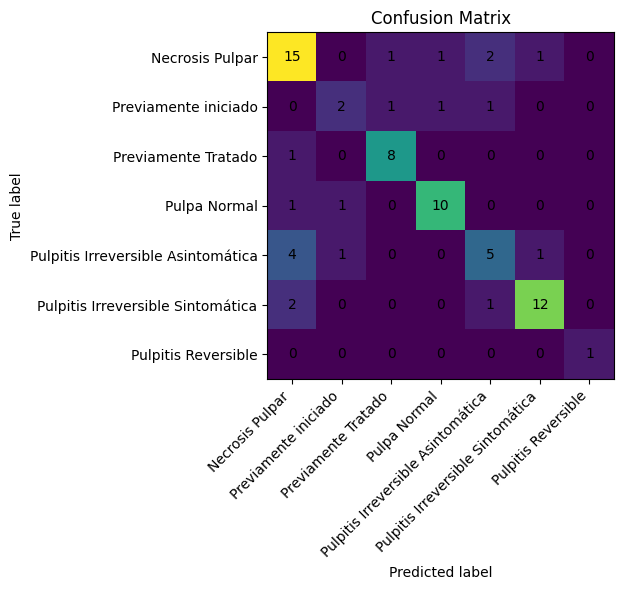

In [49]:
#Just one test:

test_combo = (
    "Dx Periapical",
    "Sensibilidad",
    "Percusión",
    "Movilidad",
    "Palpación",
    "OD",
)

test_kfold_result = run_kfold_for_combination(
    selected_columns=test_combo,
    k_folds=K_FOLDS,
    epochs=KFOLD_EPOCHS,
    batch_size=KFOLD_BATCH_SIZE,
    num_workers=KFOLD_NUM_WORKERS,
    seed=KFOLD_SEED,
)

In [ ]:
def run_massive_kfold_experiments(
    clinical_combinations,
    k_folds=5,
    epochs=50,
    batch_size=64,
    num_workers=0,
    seed=42,
):
    global massive_kfold_results
    global massive_kfold_failures

    total = len(clinical_combinations)

    for i, combo in enumerate(clinical_combinations, start=1):
        combination_name = " + ".join(combo)

        print("\n\n" + "#" * 120)
        print(f"EXPERIMENTO {i}/{total}")
        print(f"COMBINACIÓN: {combination_name}")
        print("#" * 120)

        try:
            result = run_kfold_for_combination(
                selected_columns=combo,
                k_folds=k_folds,
                epochs=epochs,
                batch_size=batch_size,
                num_workers=num_workers,
                seed=seed,
            )

            massive_kfold_results[combination_name] = result

        except Exception as e:
            print(f"❌ Error en combinación: {combination_name}")
            print(e)

            massive_kfold_failures[combination_name] = {
                "columns": combo,
                "error": str(e),
            }

    print("\n" + "=" * 120)
    print("EXPERIMENTOS K-FOLD TERMINADOS")
    print("=" * 120)
    print("Combinaciones exitosas:", len(massive_kfold_results))
    print("Combinaciones con error:", len(massive_kfold_failures))

    return massive_kfold_results

In [ ]:
debug_results = run_massive_kfold_experiments(
    clinical_combinations=clinical_combinations[:2],
    k_folds=K_FOLDS,
    epochs=3,
    batch_size=KFOLD_BATCH_SIZE,
    num_workers=KFOLD_NUM_WORKERS,
    seed=KFOLD_SEED,
)

# WARNING: Masive testing, may consume too much resourses and spend a lot of time

In [ ]:
all_kfold_results = run_massive_kfold_experiments(
    clinical_combinations=clinical_combinations,
    k_folds=K_FOLDS,
    epochs=KFOLD_EPOCHS,
    batch_size=KFOLD_BATCH_SIZE,
    num_workers=KFOLD_NUM_WORKERS,
    seed=KFOLD_SEED,
)

# Results

In [ ]:
def build_global_kfold_summary(results_dict):
    rows = []

    for name, result in results_dict.items():
        summary_df = result["kfold_summary_df"]
        best_eval = result["best_fold_eval"]

        def get_metric(metric_name, column):
            return summary_df.loc[
                summary_df["metric"] == metric_name,
                column
            ].values[0]

        rows.append({
            "combination": name,
            "num_columns": len(result["columns"]),
            "clinical_dim": result["clinical_dim"],
            "samples_count": result["samples_count"],

            "accuracy_mean": get_metric("accuracy", "mean"),
            "accuracy_std": get_metric("accuracy", "std"),

            "f1_macro_mean": get_metric("f1_macro", "mean"),
            "f1_macro_std": get_metric("f1_macro", "std"),

            "precision_macro_mean": get_metric("precision_macro", "mean"),
            "recall_macro_mean": get_metric("recall_macro", "mean"),

            "f1_weighted_mean": get_metric("f1_weighted", "mean"),
            "f1_weighted_std": get_metric("f1_weighted", "std"),

            "best_fold": result["best_fold"],
            "best_fold_accuracy": best_eval["accuracy"],
            "best_fold_f1_macro": best_eval["f1_macro"],
            "best_fold_precision_macro": best_eval["precision_macro"],
            "best_fold_recall_macro": best_eval["recall_macro"],
        })

    global_summary_df = pd.DataFrame(rows)

    global_summary_df = global_summary_df.sort_values(
        by=["f1_macro_mean", "accuracy_mean", "best_fold_f1_macro"],
        ascending=False,
    ).reset_index(drop=True)

    global_summary_df.insert(0, "rank", range(1, len(global_summary_df) + 1))

    return global_summary_df

In [ ]:
global_kfold_summary_df = build_global_kfold_summary(massive_kfold_results)

display(global_kfold_summary_df)

In [ ]:
best_global_row = global_kfold_summary_df.iloc[0]
best_global_key = best_global_row["combination"]

best_global_result = massive_kfold_results[best_global_key]
best_global_model = best_global_result["best_fold_model"]
best_global_eval = best_global_result["best_fold_eval"]

print("\n" + "=" * 100)
print("🏆 MEJOR COMBINACIÓN GLOBAL")
print("=" * 100)

print("Combinación:", best_global_key)
print("Columnas:", best_global_result["columns"])
print("Clinical dim:", best_global_result["clinical_dim"])
print("Mejor fold:", best_global_result["best_fold"])

print("\nPromedios K-Fold:")
print(f"Accuracy mean      : {best_global_row['accuracy_mean']:.4f} ± {best_global_row['accuracy_std']:.4f}")
print(f"F1 macro mean      : {best_global_row['f1_macro_mean']:.4f} ± {best_global_row['f1_macro_std']:.4f}")
print(f"F1 weighted mean   : {best_global_row['f1_weighted_mean']:.4f} ± {best_global_row['f1_weighted_std']:.4f}")

print("\nMétricas del mejor fold:")
print(f"Accuracy           : {best_global_eval['accuracy']:.4f}")
print(f"Precision macro    : {best_global_eval['precision_macro']:.4f}")
print(f"Recall macro       : {best_global_eval['recall_macro']:.4f}")
print(f"F1 macro           : {best_global_eval['f1_macro']:.4f}")
print(f"Precision weighted : {best_global_eval['precision_weighted']:.4f}")
print(f"Recall weighted    : {best_global_eval['recall_weighted']:.4f}")
print(f"F1 weighted        : {best_global_eval['f1_weighted']:.4f}")

print("\nClassification report:\n")
print(best_global_eval["classification_report"])

print("\nConfusion matrix:\n")
print(best_global_eval["confusion_matrix"])

plot_confusion_matrix(best_global_eval["confusion_matrix"], idx_to_class)

In [ ]:
#Export the result

global_kfold_summary_df.to_csv(
    "massive_kfold_combinations_summary.csv",
    index=False,
)

print("Resumen guardado en massive_kfold_combinations_summary.csv")